In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "x": [10, 0, 5, 6, 3],
    "y": [6, 7, 4, 2, 3]
}

In [3]:
df = pd.DataFrame(data)
x = df["x"].values
y = df["y"].values

In [4]:
def log_prob(theta):
    a, b = theta
    pred = a * x + b
    error = y - pred
    return -0.5 * np.sum(error**2)

In [5]:
def grad_log_prob(theta):
    a, b = theta
    pred = a * x + b
    error = y - pred
    
    da = np.sum(error * x)
    db = np.sum(error)
    
    return np.array([da, db])

In [6]:
def hmc(iterations=5000, step_size=0.01, L=20):
    theta = np.array([0.0, 0.0])
    samples = []

    for _ in range(iterations):
        current_theta = theta.copy()
        momentum = np.random.normal(0, 1, size=2)

        current_momentum = momentum.copy()

        # Leapfrog
        momentum += 0.5 * step_size * grad_log_prob(theta)

        for _ in range(L):
            theta += step_size * momentum
            if _ != L - 1:
                momentum += step_size * grad_log_prob(theta)

        momentum += 0.5 * step_size * grad_log_prob(theta)
        momentum = -momentum

        # Hamiltonian
        def H(theta, momentum):
            return -log_prob(theta) + 0.5 * np.sum(momentum**2)

        current_H = H(current_theta, current_momentum)
        proposed_H = H(theta, momentum)

        # Accept/reject
        if np.random.rand() >= np.exp(current_H - proposed_H):
            theta = current_theta  # reject

        samples.append(theta.copy())

    return np.array(samples)

In [7]:
samples = hmc()
samples

array([[ 1.10426562,  0.15260252],
       [ 0.16132537,  0.00602424],
       [ 0.93712041,  0.13887572],
       ...,
       [-0.15988291,  5.36185024],
       [-0.18094298,  5.0856429 ],
       [-0.1473903 ,  5.26238394]], shape=(5000, 2))

In [8]:
samples_post = samples[1000:]

a_mean = samples_post[:, 0].mean()
b_mean = samples_post[:, 1].mean()

print(f"Estimated a: {a_mean:.4f}")
print(f"Estimated b: {b_mean:.4f}")

Estimated a: -0.0813
Estimated b: 4.7829


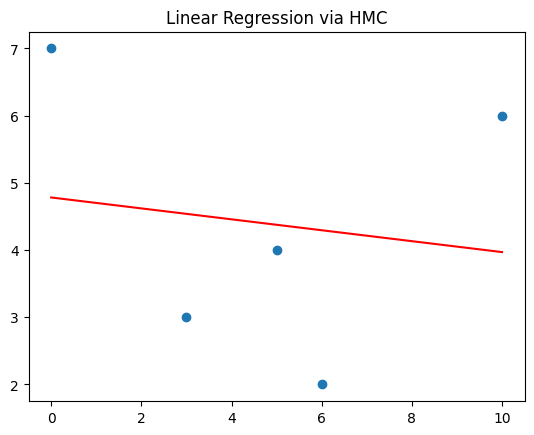

In [9]:
plt.scatter(x, y)

x_line = np.linspace(min(x), max(x), 100)
y_line = a_mean * x_line + b_mean

plt.plot(x_line, y_line, color="red")
plt.title("Linear Regression via HMC")
plt.show()